In [92]:
from typing_extensions import Literal, TypedDict
from pydantic import BaseModel, Field
from langchain_core.messages import SystemMessage, HumanMessage
from typing import Annotated, List
import operator
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
import os
from dotenv import load_dotenv
load_dotenv()
from langchain_community.utilities import GoogleSerperAPIWrapper
import pprint
import json


In [2]:
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_PROJECT"]=os.getenv("LANGSMITH_PROJECT")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["SERPER_API_KEY"] = os.getenv("SERPER_API_KEY")


In [3]:
llm = ChatGroq(model="gemma2-9b-it")

In [79]:
class Section(BaseModel):
    title: str = Field(
        description="A title of the news",
    )
    link: str = Field(
        description="A link to the news",
    )
    time_published: str = Field(
        description="A time when news published",
    )
    source: str = Field(
        description="A news chennel name",
    )
    # snippet: str = Field(
    #     description="News overview",
    # )

class Sections(BaseModel):
    sections: List[Section] = Field(
        description="Sections of the AI news",
    )

class query(BaseModel):
    news_topic: str = Field(description="string for topic")

# Augment the LLM with schema for structured output
planner = llm.with_structured_output(Sections)
newsai = llm.with_structured_output(query)


In [38]:
orchestration_instruction = """
# Orchestrator Agent Instructions

**Role:**  
You are the Orchestrator Agent in a multi-agent AI system for curating and summarizing AI-related news.

**Objective:**  
Analyze a list of news items and generate a **structured outline (plan)** for a news report.

**Input Format:**  
You will receive the latest AI news as a list of dictionaries. Each news item includes:
- **title**
- **link**
- **date** (time published)
- **source**

**Tasks:**  
1. **Analyze:** Carefully review each news item.
2. **Organize:** Arrange the news into a clear, well-structured outline. Group items by category or relevance if possible.
3. **Output:** Produce a well-organized outline (plan) based solely on the provided news information.

Return only the **structured outline** as your final output.
"""

worker_instruction = """
# Worker Agent Instructions

**Role:**  
You are a Worker Agent in news summarization system tasked with transforming a single news item into an engaging and insightful summary. make sure heading should align properly.

**Steps to Follow:**

2. **Title:**  
   - Provide a compelling and relevant title for the news.

3. **Source & Timestamp:**  
   - Immediately below the title, include the news source and publication time.

4. **Article Understanding:**  
   - Use the provided link to read and fully understand the article.

5. **Snippet:**  
   - Based on article understanding, Write a brief, engaging and factual snippet that captures the essence of the news.

6. **Summary:**  
   - Offer a concise 3-5 sentence summary that covers the key points.

7. **Analysis:**  
   - Provide a short analysis discussing the article's significance, its relation to past developments, and its potential future impact.

8. **Key Insights:**  
   - List 2-3 bullet points highlighting the most important takeaways.

9. **Original Source:**  
   - Conclude with the direct link to the original article.

**Formatting Requirements:**  
- Use clean **Markdown formatting** with clear headings and highlights.
- Do not include any additional commentary or extraneous text.
"""

news_instruction = """
You are an intelligent news-search agent. Your role is to deeply understand the user's query and generate a concise, information-rich search topic that can retrieve all relevant news articles from google serper.
below is the code where we will pass topic. topic should be string so you just have to give a small string.

def news(topic: str):
    search = GoogleSerperAPIWrapper(type="news", tbs="qdr:h24")
    results = search.results(topic)

"""

verification_instruction = """
You are an AI assistant named VerifiNews. Your role is to carefully examine each news dictionary in a list passed to you.

Each dictionary has the fields: `title`, `link`, `date`, and `source`.

Keep only those dictionaries that:
- Have a complete and meaningful `title`
- Have a valid `link` 
- Have a `date` in correct format 
- Have a valid `source`

Remove any news dictionary that is:
- duplicate
- Incomplete
- Has junk or empty values
- Has a broken or invalid URL
- Has an incorrect or missing date

Return only the cleaned list of valid news dictionaries. Do not return anything else.
"""

In [109]:
import feedparser
from datetime import datetime, timedelta, timezone
import requests

# RSS feeds organized by type
rss_feeds = {
    "Top Stories": [
        "https://www.cbc.ca/cmlink/rss-topstories",
        "https://www.thestar.com/search/?f=rss&t=article&bl=2827101&l=20",
        "https://globalnews.ca/feed/",
        "https://nationalpost.com/feed/",
    ],
    "World News": [
        "https://www.cbc.ca/cmlink/rss-world",
        "https://globalnews.ca/world/feed/",
        "http://rss.cnn.com/rss/edition_world.rss"
    ],
    "Canada News": [
        "https://www.cbc.ca/cmlink/rss-canada",
        "https://globalnews.ca/canada/feed/"
    ],
    "Business": [
        "https://www.cbc.ca/cmlink/rss-business",
        "https://www.theglobeandmail.com/report-on-business/?service=rss",
        "https://business.financialpost.com/feed/"
    ],
    "Technology": [
        "https://www.cbc.ca/cmlink/rss-technology",
        "https://www.theglobeandmail.com/technology/?service=rss"
    ],
    "Politics": [
        "https://globalnews.ca/politics/feed/",
        "https://www.cbc.ca/webfeed/rss/rss-politics"
    ],
    "Health": [
        "https://globalnews.ca/health/feed/",
        "https://www.cbc.ca/webfeed/rss/rss-health"
    ]
}

# Time setup for 24-hour filtering
now = datetime.now(timezone.utc)
print(now)
print(timedelta(days=1))
last_24hrs = now - timedelta(days=1)
print(last_24hrs)

# Final result list
all_news = []
print(rss_feeds.items())


2025-03-30 11:39:27.303578+00:00
1 day, 0:00:00
2025-03-29 11:39:27.303578+00:00
dict_items([('Top Stories', ['https://www.cbc.ca/cmlink/rss-topstories', 'https://www.thestar.com/search/?f=rss&t=article&bl=2827101&l=20', 'https://globalnews.ca/feed/', 'https://nationalpost.com/feed/']), ('World News', ['https://www.cbc.ca/cmlink/rss-world', 'https://globalnews.ca/world/feed/', 'http://rss.cnn.com/rss/edition_world.rss']), ('Canada News', ['https://www.cbc.ca/cmlink/rss-canada', 'https://globalnews.ca/canada/feed/']), ('Business', ['https://www.cbc.ca/cmlink/rss-business', 'https://www.theglobeandmail.com/report-on-business/?service=rss', 'https://business.financialpost.com/feed/']), ('Technology', ['https://www.cbc.ca/cmlink/rss-technology', 'https://www.theglobeandmail.com/technology/?service=rss']), ('Politics', ['https://globalnews.ca/politics/feed/', 'https://www.cbc.ca/webfeed/rss/rss-politics']), ('Health', ['https://globalnews.ca/health/feed/', 'https://www.cbc.ca/webfeed/rss/rs

In [110]:
last_24hrs

datetime.datetime(2025, 3, 29, 11, 39, 27, 303578, tzinfo=datetime.timezone.utc)

checkout difference b/w times.

In [111]:
# fetch_rss.py (with timeout + fallback)
def rss_news():
    rss_feeds_news = []
    for urls in rss_feeds.values():
            for url in urls:
                try:
                    # Fetch RSS with timeout
                    response = requests.get(url, timeout=5)
                    feed = feedparser.parse(response.content)

                    for entry in feed.entries:
                        # print(entry)
                        try:
                            published_time = datetime(*entry.published_parsed[:6])
                            published_time = published_time.replace(tzinfo=timezone.utc)
                            print("published_time", published_time)
                            if published_time > last_24hrs:
                                # print(entry.title)
                                news_item = {
                                    "title": entry.title,
                                    "link": entry.link,
                                    "date": published_time.strftime('%Y-%m-%d %H:%M:%S'), #todo
                                    "source": feed.feed.get("title", "Unknown Source"), #todo
                                }
                                rss_feeds_news.append(news_item)
                        except Exception as e:
                            print(f"⚠️ Entry error: {e}")
                            continue

                except requests.exceptions.Timeout:
                    print(f"⏰ Timeout: {url}")
                except Exception as e:
                    print(f"❌ Failed to fetch {url}: {e}")

    return rss_feeds_news


DB

In [8]:
# db_handler.py
import sqlite3
from datetime import datetime, timedelta, timezone

DB_NAME = "news_ai.db"

In [69]:
# Initialize database and table
def init_db():
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS news (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            title TEXT,
            link TEXT UNIQUE,
            date TEXT,
            source TEXT,
            fetched_at       
        )
    ''')
    conn.commit()
    conn.close()

# Insert news into database (skip duplicates)
def insert_news(news_list):
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    now = datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M:%S')
    print("insert start")
    for news in news_list:
        try:
            cursor.execute('''
                INSERT OR IGNORE INTO news (title, link, date, source, fetched_at)
                VALUES (?, ?, ?, ?, ?)
            ''', (news["title"], news["link"], news["date"], news["source"], now))
        except Exception:
            continue
    print("insert done")
    conn.commit()
    conn.close()


# Delete news older than X hours (default: 48 hours)
def delete_old_news(hours=48):
    threshold_time = (datetime.now(timezone.utc) - timedelta(hours=hours)).strftime('%Y-%m-%d %H:%M:%S')
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    cursor.execute("DELETE FROM news WHERE fetched_at < ?", (threshold_time,))
    conn.commit()
    conn.close()


# Get news by optional filters (e.g., keyword only)
def get_rss_news(keyword=None, limit=100):
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    print(keyword)
    query = "SELECT title, link, date, source FROM news WHERE 1=1"
    params = []

    if keyword:
        query += " AND LOWER(title) LIKE ?"
        params.append(f"%{keyword.lower()}%")

    query += " ORDER BY date DESC LIMIT ?"
    params.append(limit)

    cursor.execute(query, params)
    results = cursor.fetchall()
    conn.close()

    return [
        {"title": r[0], "link": r[1], "date": r[2], "source": r[3]}
        for r in results
    ]


In [117]:
init_db()

In [112]:
news_list = rss_news()

⏰ Timeout: https://www.cbc.ca/cmlink/rss-topstories
published_time 2025-03-30 05:50:53+00:00
published_time 2025-03-29 23:44:19+00:00
published_time 2025-03-29 22:57:56+00:00
published_time 2025-03-29 22:02:29+00:00
published_time 2025-03-29 20:22:37+00:00
published_time 2025-03-29 19:05:29+00:00
published_time 2025-03-29 18:54:30+00:00
published_time 2025-03-29 18:42:49+00:00
published_time 2025-03-29 17:26:01+00:00
published_time 2025-03-29 16:50:56+00:00
⏰ Timeout: https://www.cbc.ca/cmlink/rss-world
published_time 2025-03-29 20:22:37+00:00
published_time 2025-03-29 18:54:30+00:00
published_time 2025-03-29 18:42:49+00:00
published_time 2025-03-29 17:26:01+00:00
published_time 2025-03-29 16:50:56+00:00
published_time 2025-03-29 08:00:58+00:00
published_time 2025-03-28 16:52:25+00:00
published_time 2025-03-28 11:32:21+00:00
published_time 2025-03-27 21:28:30+00:00
published_time 2025-03-27 18:22:07+00:00
published_time 2023-04-14 20:00:28+00:00
published_time 2023-04-14 20:07:40+00:00

In [115]:
news_list

[{'title': 'Draisaitl scores in OT as Oilers beat Flames 3-2',
  'link': 'https://globalnews.ca/news/11105143/draisaitl-scores-in-ot-as-oilers-beat-flames-3-2/',
  'date': '2025-03-30 05:50:53',
  'source': ''},
 {'title': 'Trio of political parties to officially make the ballot in Calgary election',
  'link': 'https://globalnews.ca/news/11103350/trio-of-political-parties-calgary-election/',
  'date': '2025-03-29 23:44:19',
  'source': ''},
 {'title': 'Max Scherzer’s thumb leads to lat issue',
  'link': 'https://globalnews.ca/news/11104903/max-scherzers-thumb-leads-to-lat-issue/',
  'date': '2025-03-29 22:57:56',
  'source': ''},
 {'title': 'Westburg’s two homers help Orioles top Blue Jays',
  'link': 'https://globalnews.ca/news/11104871/westburgs-two-homers-help-orioles-top-blue-jays/',
  'date': '2025-03-29 22:02:29',
  'source': ''},
 {'title': '‘Tesla Takedown’ protesters swarm showrooms in response to Elon Musk’s DOGE role',
  'link': 'https://globalnews.ca/news/11104774/tesla-tak

In [118]:
insert_news(news_list=news_list)

insert start
insert done


In [ ]:
get_rss_news(keyword="canada")

In [ ]:
delete_old_news()

In [119]:
from langgraph.constants import Send

# Graph state
class State(TypedDict):
    news_topic: str  # news topic
    latest_news: list[dict]
    sections: list[Section]  # List of news sections
    completed_sections: Annotated[list, operator.add]  # All workers write to this key in parallel
    final_report: str  # Final report

# Worker state
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]

# Nodes
def google_news(topic: str):
    search = GoogleSerperAPIWrapper(type="news", tbs="qdr:h24")
    results = search.results(topic)
    #pprint.pp(results)
    
    for news in results["news"]:
        for key in ['imageUrl', 'position', 'snippet']:
            if key in news:
                del news[key] 

    #pprint.pp(results)
    return results['news'] 

def news(topic: str):
    g_news = google_news(topic)
    r_news = get_rss_news(keyword=topic)
    print("r_news = ",r_news)
    latest_news = g_news + r_news
    return latest_news

def news_ai(state: State):
    """AI agent that understand user query and generate string for news extraction"""

    news_topic = newsai.invoke(
        [
            SystemMessage(content=news_instruction),
            HumanMessage(
                content=f"Here is the user query: {state['news_topic']}"
            ),
        ]
    )
    news_topic_dict = news_topic.model_dump()
    # print("news_topic:", news_topic_dict)

    topic = news_topic.news_topic
    print(topic)
    # g_news = google_news(topic)
    # r_news = get_rss_news(keyword=topic)
    # latest_news = g_news + r_news
    latest_news = news(topic=topic)
    print("latest =", latest_news)
    return {"latest_news": latest_news}
    
def verify_news(state: State):
    verified_news = llm.invoke(
        [
            SystemMessage(content=verification_instruction),
            HumanMessage(
                content=f"Here is all the news details: {state['latest_news']}"
            ),
        ]
    )
    print("verified = ", verified_news)
    return {"latest_news": verified_news}


def orchestrator(state: State):
    """Orchestrator that generates a plan for the news"""

    #print("Orchestrator is activated, here output will be lst of section: State")
    # latest_news = news(state["news_topic"])
    # print(latest_news)
    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content=orchestration_instruction),
            HumanMessage(
                content=f"Here is the latest AI news: {state['latest_news']}"
            ),
        ]
    )
    #print(state["topic"])
    print("Report Sections:",report_sections)

    return {"sections": report_sections.sections}

def llm_call(state: WorkerState):
    """Worker writes a section of the report"""

    #print("llm_call is activated, here output will be lst of section: WorkerState, section = ")
    # print(f"state[section] = {state['section']}")
    # Generate section
    section = llm.invoke(
        [
            SystemMessage(content=worker_instruction),
            HumanMessage(
                content=f"Here is the news_title: {state['section'].title},\
                      news_link: {state['section'].link}, time_published: {state['section'].time_published},\
                          news_source: {state['section'].source}" # news_snippet: {state['section'].snippet}
            ),
        ]
    )

    #print(f"{state['section']},\n {type(state['section'])}")
    # Write the updated section to completed sections
    #print("section = \n", section)
    return {"completed_sections": [section.content]}


def synthesizer(state: State):
    """Synthesize full report from sections"""

    #print("synthesizer is activated, here output will be lst of completed sections: State")

    # List of completed sections
    completed_sections = state["completed_sections"]
    #print("completed_sections",completed_sections)
    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    #print("completed_report_sections",completed_report_sections)

    return {"final_report": completed_report_sections}


# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""
    #print([s for s in state["sections"]])
    # Kick off section writing in parallel via Send() API
    return [Send("llm_call", {"section": s}) for s in state["sections"]]

In [ ]:
news("israel")

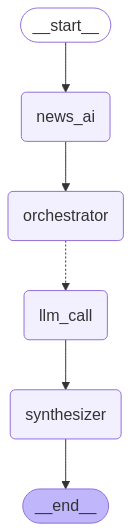

In [120]:
# Build workflow
builder = StateGraph(State)

# Add the nodes
builder.add_node("news_ai", news_ai)
# builder.add_node("verify_news", verify_news)
builder.add_node("orchestrator", orchestrator)
builder.add_node("llm_call", llm_call)
builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
builder.add_edge(START, "news_ai")
builder.add_edge("news_ai", "orchestrator")
# builder.add_edge("news_ai", "verify_news")
# builder.add_edge("verify_news", "orchestrator")
builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
builder.add_edge("llm_call", "synthesizer")
builder.add_edge("synthesizer", END)

# Compile the workflow
graph = builder.compile()

graph

In [127]:
# Invoke
state = graph.invoke({"news_topic": "gen z"})

Gen Z news
Gen Z news
r_news =  []
latest = [{'title': 'Gen Z are terrified of layoffs and the spiraling economy—so they’re copying Steve Jobs and showing up to the office in uniforms', 'link': 'https://fortune.com/2025/03/30/gen-z-millennial-layoffs-economic-anxiety-office-uniform-productivity-hack/', 'date': '3 hours ago', 'source': 'Fortune'}, {'title': 'Gen Z Puzzled by Millennial Fashion Item, Woman Has Existential Answer', 'link': 'https://www.newsweek.com/woman-answers-gen-z-question-millennial-fashion-heels-2051934', 'date': '4 hours ago', 'source': 'Newsweek'}, {'title': 'Millennials and Gen Z lead the herb garden revival', 'link': 'https://www.myjournalcourier.com/news/article/millennials-gen-z-lead-herb-garden-revival-20200108.php', 'date': '16 hours ago', 'source': 'Jacksonville Journal-Courier'}, {'title': 'Why Gen Z is faking maternity photos instead of having kids', 'link': 'https://jingdaily.com/posts/why-gen-z-is-faking-maternity-photos-instead-of-having-kids', 'date':

In [125]:
state

{'news_topic': ' war',
 'latest_news': [{'title': 'Ukraine-Russia war latest: Putin’s forces launch over 150 deadly glide bombs in huge air attack',
   'link': 'https://www.independent.co.uk/news/world/europe/ukraine-russia-war-latest-map-trump-putin-b2723998.html',
   'date': '1 hour ago',
   'source': 'The Independent'},
  {'title': 'Russia-Ukraine war: List of key events, day 1,130',
   'link': 'https://www.aljazeera.com/news/2025/3/30/russia-ukraine-war-list-of-key-events-day-1130',
   'date': '5 hours ago',
   'source': 'Al Jazeera'},
  {'title': "Ukraine accuses Russia of war crime for 'deliberate' strike on hospital",
   'link': 'https://abcnews.go.com/International/ukraine-accuses-russia-war-crime-deliberate-strike-hospital/story?id=120308789',
   'date': '53 minutes ago',
   'source': 'ABC News'},
  {'title': 'Opinion: Sasha’s story brings Ukraine war home to Maine',
   'link': 'https://www.sunjournal.com/2025/03/30/opinion-sashas-story-brings-ukraine-war-home-to-maine/',
   '

In [126]:
from IPython.display import Markdown
Markdown(state["final_report"])

## Putin Launches Massive Air Strike on Ukraine with Over 150 Glide Bombs

**Source:** The Independent  **Timestamp:** 1 hour ago

**Snippet:** 

Russian forces have intensified their offensive in Ukraine with a large-scale air attack involving over 150 glide bombs targeting various regions. 

**Summary:**

In a significant escalation of the conflict, Russia launched a massive air attack on Ukraine, deploying more than 150 deadly glide bombs across multiple locations. Ukrainian officials have reported intense bombardment in several regions, highlighting the increasing ferocity of the Russian offensive. The attack comes amidst ongoing Ukrainian counteroffensive efforts and amid heightened tensions following Russia's withdrawal from the Black Sea grain deal. 

**Analysis:**

This massive air assault demonstrates Russia's determination to inflict heavy damage on Ukrainian infrastructure and personnel. It also signals a potential shift in Russian strategy, focusing on aerial bombardment to weaken Ukrainian defenses and disrupt supply lines. The attack's timing, coinciding with Ukraine's counteroffensive and the grain deal's collapse, further underscores the volatile nature of the conflict. 

**Key Insights:**

* Russia has significantly escalated its military campaign in Ukraine with a large-scale air attack.
* The use of over 150 glide bombs highlights Russia's potential shift towards intensified aerial bombardment strategies.
* The attack's timing suggests a deliberate attempt by Russia to undermine Ukrainian counteroffensive efforts and exert pressure on the international community.

**Original Source:** https://www.independent.co.uk/news/world/europe/ukraine-russia-war-latest-map-trump-putin-b2723998.html 


---

## Russia-Ukraine War: Day 1,130 

**Source:** Al Jazeera  **Timestamp:** 5 hours ago

**Snippet:**  
Intense fighting continues in eastern Ukraine as Russian forces intensify their offensive, Ukrainian officials report drone attacks on Russian territory, and diplomatic efforts remain stalled.

**Summary:**
On day 1,130 of the Russia-Ukraine war, heavy fighting erupted in the eastern Donbas region, with Russia pushing for territorial gains. Ukrainian forces reported repelling several attacks, but acknowledged significant losses. Meanwhile, Ukraine claimed responsibility for drone strikes targeting Russian military infrastructure and civilian facilities, marking an escalation in the conflict. Diplomatic channels remain largely inactive, with no signs of a breakthrough in peace negotiations. 

**Analysis:**
The intensification of fighting in the Donbas region suggests Russia is determined to make territorial gains despite heavy losses. The drone attacks on Russian soil signal a shift in Ukraine's strategy, aiming to strike at the heart of Russian operations. The lack of progress in diplomatic efforts raises concerns about the possibility of a protracted and bloody war. 

**Key Insights:**
-  Russia continues its offensive in the Donbas region, despite Ukrainian resistance.
- Ukraine escalates its campaign with drone attacks on Russian territory. 
- Diplomatic efforts remain stalled, increasing the risk of a prolonged conflict.

**Original Source:** https://www.aljazeera.com/news/2025/3/30/russia-ukraine-war-list-of-key-events-day-1130 


---

##  Ukraine Accuses Russia of War Crime for 'Deliberate' Hospital Strike

**Source:** ABC News  **Timestamp:** 53 minutes ago

**Snippet:** 

Ukraine has accused Russia of committing a war crime after a Russian missile strike hit a maternity and children's hospital in the besieged city of Mariupol, killing three people and injuring 17.

**Summary:** 

The Ukrainian government condemned the attack as a deliberate act of terror and called for international condemnation.  The strike on the hospital, which was sheltering hundreds of civilians, drew widespread international outrage. The Russian military claimed the building was being used by Ukrainian forces, a claim vehemently denied by Ukrainian officials.

**Analysis:**

This incident underscores the brutality of the ongoing conflict in Ukraine and raises serious concerns about potential war crimes. The targeting of a civilian hospital is a grave violation of international law and further tarnishes Russia's reputation on the world stage.

**Key Insights:**

* The attack on the Mariupol hospital resulted in civilian casualties and heightened international condemnation of Russia's actions.
* Ukraine accused Russia of deliberately targeting the hospital, alleging it was a war crime.
* Russia claimed the hospital was being used by Ukrainian forces, a claim refuted by Ukrainian officials.

**Original Source:** https://abcnews.go.com/International/ukraine-accuses-russia-war-crime-deliberate-strike-hospital/story?id=120308789 


---

## Opinion: Sasha's Story Brings Ukraine War Home to Maine

**Source & Timestamp:** Lewiston Sun Journal, 4 hours ago

**Snippet:** 

A young Ukrainian refugee's story in Maine highlights the human cost of the war in Ukraine, prompting reflection on the global impact of the conflict.

**Summary:**

The article shares the story of Sasha, a Ukrainian refugee who has recently arrived in Maine. Her experience fleeing her home country and adjusting to life in a new place underscores the devastating impact of the war on ordinary people. The author argues that Sasha's story brings the realities of the conflict home to Maine residents, fostering empathy and understanding.

**Analysis:**

This opinion piece uses a personal narrative to connect readers to the broader issue of the war in Ukraine. By focusing on Sasha's individual experience, the author aims to transcend geopolitical discussions and emphasize the human cost of war. It serves as a reminder that the conflict has far-reaching consequences, impacting lives beyond the borders of Ukraine.

**Key Insights:**

* The war in Ukraine is not just a distant conflict; it has real and tangible consequences for individuals worldwide.
* Personal stories can be powerful tools for fostering empathy and understanding of complex global issues.
* Refugee experiences shed light on the human cost of war and the challenges faced by displaced populations.

**Original Source:** https://www.sunjournal.com/2025/03/30/opinion-sashas-story-brings-ukraine-war-home-to-maine/ 




---

## Eid of Sadness': Palestinians in Gaza Mark Muslim Holiday with Dwindling Food and No End to War

**Source & Timestamp:** AP News - 35 minutes ago

**Snippet:**  With dwindling food supplies and the threat of war lingering, Palestinians in Gaza are marking Eid al-Fitr with a heavy heart. 

**Summary:** 
The joyous occasion of Eid al-Fitr, marking the end of Ramadan, has been overshadowed by the ongoing conflict between Israel and Hamas. In Gaza, the humanitarian crisis deepens with limited food and essential resources. Many families struggle to celebrate traditionally, facing uncertainty about the future as the war shows no signs of abating.

**Analysis:**  
This Eid al-Fitr represents a stark contrast to the celebrations of previous years in Gaza.  The ongoing conflict has exacerbated the already challenging living conditions, adding another layer of sorrow to the festivities. The absence of a ceasefire and the continued threat of violence cast a dark shadow over the holiday, highlighting the desperate need for a peaceful resolution.

**Key Insights:**

*  The conflict in Gaza has significantly impacted the lives of Palestinians, even on religious holidays.
*  The humanitarian situation in Gaza is deteriorating, with dwindling food supplies and limited access to essential services.
*  The absence of a ceasefire and the continued violence threaten the prospects for peace and stability in the region.

**Original Source:** https://apnews.com/article/israel-palestinians-hamas-war-news-03-30-2025-ceasefire-hostages-9c621f136816d4f61897904fa4b4e395 
